In [1]:

import gymnasium as gym
import numpy as np
import random
from collections import deque
from sklearn.neural_network import MLPRegressor
from sklearn.exceptions import NotFittedError
import warnings

# Suppress sklearn warnings about stochastic optimizer usage in partial_fit
warnings.filterwarnings("ignore")

# Hyperparameters
GAMMA = 0.99           # Discount factor
EPSILON = 5.0          # Exploration rate
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.05
LEARNING_RATE = 0.0001 # 0.001
BATCH_SIZE = 420
MEMORY_SIZE = 6000

## DQN Agent
This class wraps the MLPRegressor to behave like a Deep Q-Network.

Key Mathematical Concept: We are trying to minimize the Temporal Difference (TD) error:
$L = (y_j - Q(s_j, a_j))^2$


In [2]:
class SklearnDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON
        
        # We use MLPRegressor as our Q-function approximator
        self.model = MLPRegressor(
            hidden_layer_sizes=(24, 24), 
            activation='relu', 
            solver='adam', 
            learning_rate_init=LEARNING_RATE,
            warm_start=True, # Important: keeps previous weights
            max_iter=1       # Important: only 1 step of optimization per partial_fit
        )
        
        # Hack: We need to initialize the model with dummy data so partial_fit works later
        # We create dummy inputs and dummy targets
        dummy_X = np.zeros((1, state_size))
        dummy_y = np.zeros((1, action_size))
        self.model.partial_fit(dummy_X, dummy_y)

    def remember(self, state, action, reward, next_state, done):
        """Store experience in replay buffer"""
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """Epsilon-greedy action selection"""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        
        # Predict Q-values for the current state
        act_values = self.model.predict(state)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        """Training step using a batch from memory"""
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        
        # Prepare arrays for bulk prediction (optimization for speed)
        states = np.array([i[0][0] for i in minibatch])
        next_states = np.array([i[3][0] for i in minibatch])
        
        # Batch prediction for current Q-values and Next Q-values
        # Note: In PyTorch this is done with gradients; here we predict first
        current_qs = self.model.predict(states)
        next_qs = self.model.predict(next_states)
        
        X_train = []
        y_train = []

        for i, (state, action, reward, next_state, done) in enumerate(minibatch):
            target = reward
            if not done:
                # Bellman Equation: R + Gamma * max(Q(next_state))
                target = reward + GAMMA * np.max(next_qs[i])
            
            # We want the network to map State -> [Q_val_1, Q_val_2]
            # We only want to update the Q-value for the action we took.
            # So we use the *current* prediction as the target, and replace 
            # only the index of the action taken.
            target_f = current_qs[i]
            target_f[action] = target
            
            X_train.append(state[0])
            y_train.append(target_f)

        # Update the model weights
        self.model.partial_fit(np.array(X_train), np.array(y_train))

        if self.epsilon > EPSILON_MIN:
            self.epsilon *= EPSILON_DECAY

# Training Loop

This loop interacts with the CartPole environment.

In [3]:
# Create Environment
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

agent = SklearnDQNAgent(state_size, action_size)

EPISODES = 200 
scores = []  # List to store scores for plotting

print(f"Training on {env.spec.id} with Sklearn MLP...")

for e in range(EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    
    score = 0
    done = False
    truncated = False
    
    while not (done or truncated):
        action = agent.act(state)
        
        next_state, reward, done, truncated, _ = env.step(action)
        # Distinguir entre fallo y éxito
        if done:
            reward = -25 if score < 500 else 24  # Penalizar solo si cayó antes
        next_state = np.reshape(next_state, [1, state_size])
        
        agent.remember(state, action, reward, next_state, done)
        
        state = next_state
        score += 1
        
        # Training step
        agent.replay(BATCH_SIZE)
        
    # Store the score for this episode
    scores.append(score)
    print(f"Episode: {e+1}/{EPISODES}, Score: {score}, Epsilon: {agent.epsilon:.2f}")

env.close()

Training on CartPole-v1 with Sklearn MLP...
Episode: 1/200, Score: 15, Epsilon: 5.00
Episode: 2/200, Score: 11, Epsilon: 5.00
Episode: 3/200, Score: 32, Epsilon: 5.00
Episode: 4/200, Score: 40, Epsilon: 5.00
Episode: 5/200, Score: 27, Epsilon: 5.00
Episode: 6/200, Score: 11, Epsilon: 5.00
Episode: 7/200, Score: 17, Epsilon: 5.00
Episode: 8/200, Score: 22, Epsilon: 5.00
Episode: 9/200, Score: 33, Epsilon: 5.00
Episode: 10/200, Score: 92, Epsilon: 5.00
Episode: 11/200, Score: 15, Epsilon: 5.00
Episode: 12/200, Score: 11, Epsilon: 5.00
Episode: 13/200, Score: 9, Epsilon: 5.00
Episode: 14/200, Score: 16, Epsilon: 5.00
Episode: 15/200, Score: 11, Epsilon: 5.00
Episode: 16/200, Score: 12, Epsilon: 5.00
Episode: 17/200, Score: 17, Epsilon: 5.00
Episode: 18/200, Score: 20, Epsilon: 5.00
Episode: 19/200, Score: 21, Epsilon: 0.00
Episode: 20/200, Score: 9, Epsilon: 0.00
Episode: 21/200, Score: 11, Epsilon: 0.00
Episode: 22/200, Score: 16, Epsilon: 0.00
Episode: 23/200, Score: 13, Epsilon: 0.00
E

# Visualization and testing

In [4]:
# Visualize the trained agent
env = gym.make("CartPole-v1", render_mode="human")
state, _ = env.reset()
state = np.reshape(state, [1, state_size])

print("Starting Visual Test...")
try:
    for _ in range(500):
        action = agent.act(state) # Will use trained model (low epsilon)
        next_state, reward, done, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])
        state = next_state
        
        if done or truncated:
            print("Dropped!")
            state, _ = env.reset()
            state = np.reshape(state, [1, state_size])
            break
except KeyboardInterrupt:
    print("Stopped.")
finally:
    env.close()

Starting Visual Test...
Dropped!


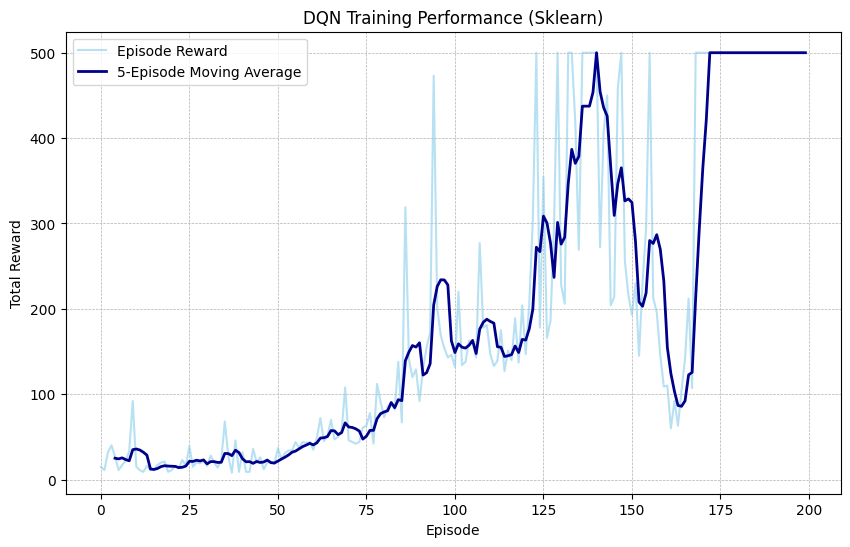

In [5]:

import matplotlib


if not hasattr(matplotlib.rcParams, '_get'):
    def _get_patch(key, default=None):
        return matplotlib.rcParams.get(key, default)
    matplotlib.rcParams._get = _get_patch

import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(scores, window=5):
    plt.figure(figsize=(10, 6))
    
    plt.plot(scores, label='Episode Reward', color='skyblue', alpha=0.6)
    
    if len(scores) >= window:
        moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
        plt.plot(range(window-1, len(scores)), moving_avg, 
                 label=f'{window}-Episode Moving Average', 
                 color='darkblue', linewidth=2)
    
    plt.ylabel('Total Reward')
    plt.xlabel('Episode')
    plt.title('DQN Training Performance (Sklearn)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

plot_learning_curve(scores)